# M8.3G — Normalisation ladder

Plan: [`plans/milestone_08/08_single_view_localization_plan.md`](../../plans/milestone_08/08_single_view_localization_plan.md).  
**Partial in Final Report** — report uses per-view z-score; ablation tables are local.

Results: `checkpoints/m8/m08_3g_normalisation/`.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


  error: subprocess-exited-with-error
  
  × Building wheel for gummybear-tomography (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [18 lines of output]
      running bdist_wheel
      running build
      running build_py
      running egg_info
      writing src/gummybear_tomography.egg-info/PKG-INFO
      writing dependency_links to src/gummybear_tomography.egg-info/dependency_links.txt
      writing requirements to src/gummybear_tomography.egg-info/requires.txt
      writing top-level names to src/gummybear_tomography.egg-info/top_level.txt
      reading manifest file 'src/gummybear_tomography.egg-info/SOURCES.txt'
      adding license file 'LICENSE'
      writing manifest file 'src/gummybear_tomography.egg-info/SOURCES.txt'
      installing to build/bdist.macosx-13.0-arm64/wheel
      running install
      running install_lib
      running install_egg_info
      Copying src/gummybear_tomography.egg-info to build/bdist.macosx-13.0-arm64/wheel/./gummybear_tomography

In [2]:
from tomography_ml_validation.milestone_08 import m8_corpus_paths, describe_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
paths = m8_corpus_paths(ROOT, data_mode=DATA_MODE)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(paths))


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache


In [3]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import torch

from tomography_ml import get_device
from tomography_ml.gummybear_data_catalog.task_dataset import build_task_dataset
from tomography_ml.studies import M8_CANONICAL_LR_BY_ARCH
import tomography_ml_validation.milestone_08.validation as m8_validation
from gummybear_validation.notebook_tools import run_installed_pytest_test

from tomography_ml_validation.milestone_08 import DEFAULT_N_REPEAT

SMOKE = False
RUN_STUDY = None  # None = auto (run when runs CSV missing)
N_REPEAT = DEFAULT_N_REPEAT
BASE_SEED = 0
NUM_EPOCHS = 40 if SMOKE else 200
EARLY_STOP = 25 if SMOKE else 40

device = get_device()
print(f"device={device}")
print("canonical LRs", M8_CANONICAL_LR_BY_ARCH)


device=mps
canonical LRs {'pooled': 0.001, 'fourier': 0.03, 'flatten': 0.0003}


In [4]:
from tomography_ml_validation.milestone_08 import (
    DEFAULT_N_REPEAT,
    load_m8_catalog_rows,
    load_win3g_results,
    plot_win3g_results,
    run_win3g_normalisation_study,
    summarize_win3g,
    win3g_results_dir,
    win3_grids_summary,
)

results_dir = win3g_results_dir(ROOT)


## Milestone 8 Step 3G predefined grid

In [5]:
display(win3_grids_summary()['3G_normalisation'])
run_installed_pytest_test(m8_validation, "test_m8_3g_selected_normalisation_is_per_image_zscore")


,name,image_normalize,description,diagnostic
0,raw,none,"raw float, no normalisation",False
1,train_split_zscore,train_split_zscore,training-split global z-score (mean/std from t...,False
2,per_image_zscore,per_image_zscore,per-image z-score (diagnostic dynamic-range re...,True
3,per_image_minmax,per_image_minmax,"per-image min/max to [0,1] (diagnostic)",True


M8.3G
Test executed: test_m8_3g_selected_normalisation_is_per_image_zscore()

pytest:
../../venv/lib/python3.12/site-packages/tomography_ml_validation/milestone_08/validation.py . [100%]
============================== 1 passed in 1.65s ===============================

Test proves: Milestone 8 Step 3G selected normalisation is per-view z-score.


## Train / validation study

In [6]:
rows = load_m8_catalog_rows(ROOT, data_mode=DATA_MODE)
summary_df, runs_df = load_win3g_results(ROOT)
should_run = RUN_STUDY if RUN_STUDY is not None else (runs_df is None or runs_df.empty)
if should_run:
    summary_df, runs_df, _ = run_win3g_normalisation_study(
        rows,
        device=device,
        num_epochs=NUM_EPOCHS,
        early_stop_patience=EARLY_STOP,
        results_dir=results_dir,
        n_repeat=N_REPEAT,
        base_seed=BASE_SEED,
    )
else:
    print("Loaded existing runs CSV — set RUN_STUDY=True to retrain.")
display(summary_df)



######## M8 Step 3G normalisation=raw repeat 1/5  seed=0 ########
  fourier_base_mlp rep 1 epoch 001/200  train_loss=33.20822  val_RMSE=5.1253  best=5.1253*  stall=0/40
  fourier_base_mlp rep 1 epoch 002/200  train_loss=30.69535  val_RMSE=5.1760  best=5.1253   stall=1/40
  fourier_base_mlp rep 1 epoch 003/200  train_loss=27.88612  val_RMSE=4.8666  best=4.8666*  stall=0/40
  fourier_base_mlp rep 1 epoch 004/200  train_loss=28.15983  val_RMSE=4.8625  best=4.8625*  stall=0/40
  fourier_base_mlp rep 1 epoch 005/200  train_loss=25.33410  val_RMSE=4.4062  best=4.4062*  stall=0/40
  fourier_base_mlp rep 1 epoch 006/200  train_loss=26.24557  val_RMSE=4.5696  best=4.4062   stall=1/40
  fourier_base_mlp rep 1 epoch 007/200  train_loss=22.55350  val_RMSE=4.0575  best=4.0575*  stall=0/40
  fourier_base_mlp rep 1 epoch 008/200  train_loss=19.58191  val_RMSE=4.0043  best=4.0043*  stall=0/40
  fourier_base_mlp rep 1 epoch 009/200  train_loss=17.73950  val_RMSE=3.8135  best=3.8135*  stall=0/40
  four

,experiment_id,win,architecture_factor,hypothesis,variant,head_type,downsample,encoder_channels,architecture_config,parameter_count,...,diagnostic,train_RMSE_total_mean,train_RMSE_total_std,validation_RMSE_total_mean,validation_RMSE_total_std,best_validation_RMSE_total_mean,best_validation_RMSE_total_std,run_group,n_repeat,seeds
7,win3g__flatten_base_mlp,3G,intensity_normalisation,per_view_zscore_elevated_standard,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,True,0.762637,0.114142,1.139977,0.092515,1.139977,0.092515,per_image_zscore::flatten_base_mlp,5,"0,1,2,3,4"
6,win3g__fourier_base_mlp,3G,intensity_normalisation,per_view_zscore_elevated_standard,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,True,0.836314,0.100490,1.250882,0.032488,1.250882,0.032488,per_image_zscore::fourier_base_mlp,5,"0,1,2,3,4"
10,win3g__flatten_base_mlp,3G,intensity_normalisation,per_view_zscore_elevated_standard,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,True,0.805353,0.193034,1.526880,0.137847,1.526880,0.137847,per_image_minmax::flatten_base_mlp,5,"0,1,2,3,4"
9,win3g__fourier_base_mlp,3G,intensity_normalisation,per_view_zscore_elevated_standard,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,True,1.029889,0.131744,1.574071,0.074008,1.574071,0.074008,per_image_minmax::fourier_base_mlp,5,"0,1,2,3,4"
3,win3g__fourier_base_mlp,3G,intensity_normalisation,per_view_zscore_elevated_standard,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,False,1.015003,0.129096,1.854796,0.022016,1.854796,0.022016,train_split_zscore::fourier_base_mlp,5,"0,1,2,3,4"
4,win3g__flatten_base_mlp,3G,intensity_normalisation,per_view_zscore_elevated_standard,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,False,1.084573,0.228352,1.905459,0.028253,1.905459,0.028253,train_split_zscore::flatten_base_mlp,5,"0,1,2,3,4"
8,win3g__pooled_base_base,3G,intensity_normalisation,per_view_zscore_elevated_standard,pooled_base_base,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,...,True,1.605798,0.057723,1.965727,0.055606,1.965727,0.055606,per_image_zscore::pooled_base_base,5,"0,1,2,3,4"
5,win3g__pooled_base_base,3G,intensity_normalisation,per_view_zscore_elevated_standard,pooled_base_base,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,...,False,2.715216,0.530393,2.943882,0.309782,2.943882,0.309782,train_split_zscore::pooled_base_base,5,"0,1,2,3,4"
11,win3g__pooled_base_base,3G,intensity_normalisation,per_view_zscore_elevated_standard,pooled_base_base,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,...,True,3.118908,0.209088,3.282479,0.181356,3.282479,0.181356,per_image_minmax::pooled_base_base,5,"0,1,2,3,4"
0,win3g__fourier_base_mlp,3G,intensity_normalisation,per_view_zscore_elevated_standard,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,False,3.392539,1.834325,3.572812,1.397917,3.572812,1.397917,raw::fourier_base_mlp,5,"0,1,2,3,4"


## Results

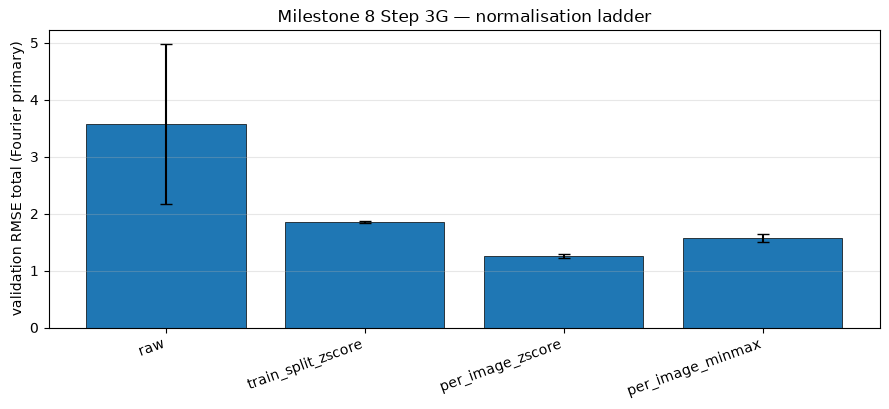

- raw: mean val RMSE 3.573.

- train_split_zscore: mean val RMSE 1.855.

- per_image_zscore: mean val RMSE 1.251.

- per_image_minmax: mean val RMSE 1.574.

- Elevated standard: per_image_zscore (per-view z-score) for downstream M9/M10.

In [7]:
fig = plot_win3g_results(summary_df)
plt.show()
for line in summarize_win3g(summary_df):
    display(Markdown(f"- {line}"))


## Conclusion

Per image z-score performs best and will be used for image normalization.